In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('financial dataset for analysis portfolio.xlsx')
df.head(5)

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,NaN,Company has responded to the consumer and the ...,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the ...,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a ...",NaN,In progress,NaN
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes


# Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62509 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     51658 non-null  object        
 9   Company public response       60341 non-null  object        
 10  Company response to consumer  62516 non-null  object        
 11  Timely response?            

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Missing values count and percentage 
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
})

# show only those columns where their is missing value
print(missing_df[missing_df['Missing Count'] > 0])

                         Missing Count  Missing %
Sub-product                          7       0.01
Sub-issue                        10858      17.37
Company public response           2175       3.48
Timely response?                  1494       2.39


In [8]:
 # Sub-issue -> every issue does not have sub issue
df['Sub-issue'] = df['Sub-issue'].fillna('Not Specified')

# Company public response -> company did not responded publically
df['Company public response'] = df['Company public response'].fillna('No Public Response')

# Timely response -> In progress complaints did not answerd
df['Timely response?'] = df['Timely response?'].fillna('Unknown')

In [9]:
# verifying that thier should not be any missing value 
print("Missing values after cleaning:")
print(df.isnull().sum())
print()
print(f"Total rows: {df.shape[0]:,}")

Missing values after cleaning:
Complaint ID                    0
Submitted via                   0
Date submitted                  0
Date received                   0
State                           0
Product                         0
Sub-product                     7
Issue                           0
Sub-issue                       0
Company public response         0
Company response to consumer    0
Timely response?                0
dtype: int64

Total rows: 62,516


In [10]:
# which row sub product is missing 
print(df[df['Sub-product'].isnull()][['Product', 'Sub-product']])

                           Product Sub-product
5623   Checking or savings account         NaN
14554  Checking or savings account         NaN
39878  Checking or savings account         NaN
40582  Checking or savings account         NaN
42790  Checking or savings account         NaN
55010  Checking or savings account         NaN
62288  Checking or savings account         NaN


In [11]:
# filling the missing value and verifying 
df['Sub-product'] = df['Sub-product'].fillna('Not Specified')

# Final verify
print(df.isnull().sum().sum()) 
print(f"Final shape: {df.shape}")

0
Final shape: (62516, 12)


# Feature engineering 

In [12]:
df["Date submitted"].dt.year      
df["Date submitted"].dt.month     
df["Date submitted"].dt.day_name() 

0           Sunday
1           Friday
2        Wednesday
3           Monday
4        Wednesday
           ...    
62511       Sunday
62512       Monday
62513    Wednesday
62514       Friday
62515      Tuesday
Name: Date submitted, Length: 62516, dtype: object

In [13]:
# Date feature 
df['Year'] = df['Date submitted'].dt.year
df['Month'] = df['Date submitted'].dt.month
df['Month_Name'] = df['Date submitted'].dt.strftime('%b')  
df['Day_of_Week'] = df['Date submitted'].dt.day_name()     
df['Quarter'] = df['Date submitted'].dt.quarter            

# in how many days company responded 
df['Response_Days'] = (df['Date received'] - df['Date submitted']).dt.days

# verifying
print(df[['Date submitted', 'Year', 'Month', 'Month_Name', 
          'Day_of_Week', 'Quarter', 'Response_Days']].head(10))

  Date submitted  Year  Month Month_Name Day_of_Week  Quarter  Response_Days
0     2021-10-24  2021     10        Oct      Sunday        4              3
1     2020-04-24  2020      4        Apr      Friday        2              0
2     2022-07-27  2022      7        Jul   Wednesday        3              0
3     2023-07-10  2023      7        Jul      Monday        3              1
4     2022-07-27  2022      7        Jul   Wednesday        3              1
5     2022-11-23  2022     11        Nov   Wednesday        4              0
6     2021-05-04  2021      5        May     Tuesday        2              0
7     2021-01-24  2021      1        Jan      Sunday        1              0
8     2022-03-18  2022      3        Mar      Friday        1              0
9     2022-11-14  2022     11        Nov      Monday        4              0


In [14]:
print("Response Days Statistics:")
print(df['Response_Days'].describe())
print()

# checing for Negative values(their might be data error)
print(f"Negative values: {(df['Response_Days'] < 0).sum()}")

# how many Same day response are their 
same_day = (df['Response_Days'] == 0).sum()
print(f"Same day response: {same_day:,} ({same_day/len(df)*100:.1f}%)")

Response Days Statistics:
count    62516.000000
mean         1.224886
std          5.649298
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: Response_Days, dtype: float64

Negative values: 0
Same day response: 49,634 (79.4%)


In [15]:
# More than 7 days reponse time compliants
slow = df[df['Response_Days'] > 7]
print(f"Slow responses (>7 days): {len(slow):,} ({len(slow)/len(df)*100:.1f}%)")

# which product has more delay
print()
print("Slow responses by Product:")
print(slow['Product'].value_counts())

Slow responses (>7 days): 2,443 (3.9%)

Slow responses by Product:
Product
Checking or savings account                                                     826
Credit card or prepaid card                                                     611
Mortgage                                                                        362
Credit reporting, credit repair services, or other personal consumer reports    265
Debt collection                                                                 180
Money transfer, virtual currency, or money service                              142
Vehicle loan or lease                                                            30
Payday loan, title loan, or personal loan                                        24
Student loan                                                                      3
Name: count, dtype: int64


In [16]:
df.to_csv('complaints_cleaned.csv', index=False)
print(f" Saved! Shape: {df.shape}")
print(f"Total columns: {df.shape[1]}")
print(df.columns.tolist())

 Saved! Shape: (62516, 18)
Total columns: 18
['Complaint ID', 'Submitted via', 'Date submitted', 'Date received', 'State', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company public response', 'Company response to consumer', 'Timely response?', 'Year', 'Month', 'Month_Name', 'Day_of_Week', 'Quarter', 'Response_Days']


# Yearly Complaints Trend

In [17]:
# Data prepare 
yearly = df.groupby('Year').size().reset_index(name='Complaints')
print(yearly)

   Year  Complaints
0  2017        5394
1  2018        7872
2  2019        7075
3  2020        8942
4  2021       11149
5  2022       12953
6  2023        9131


C:\Users\Namrata\AppData\Local\Temp\ipykernel_3752\602316044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=yearly, x='Year', y='Complaints',


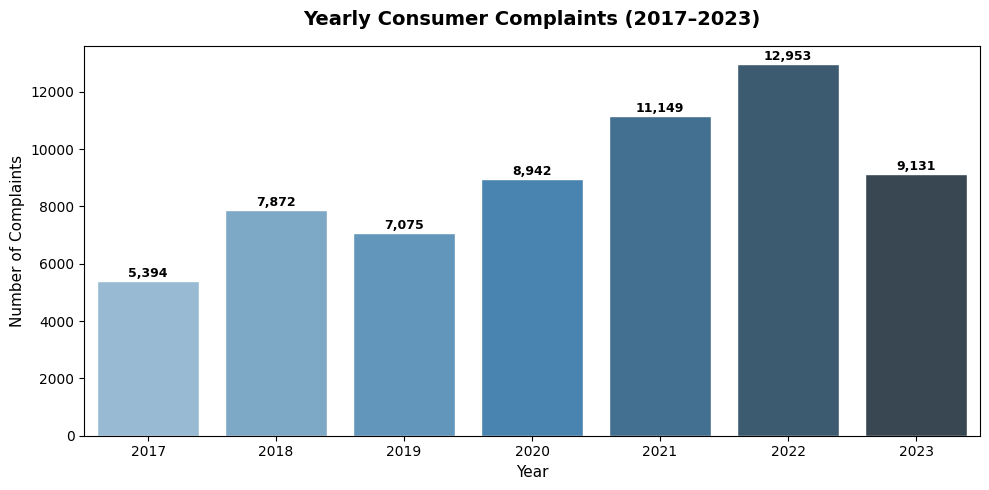

In [18]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(data=yearly, x='Year', y='Complaints', 
                 palette='Blues_d', edgecolor='white')

# show value for each bar
for bar, val in zip(ax.patches, yearly['Complaints']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 150,
            f'{val:,}',
            ha='center', fontsize=9, fontweight='bold')

plt.title('Yearly Consumer Complaints (2017–2023)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11)
plt.ylabel('Number of Complaints', fontsize=11)
plt.tight_layout()
plt.show()

# Product-wise Complaints


C:\Users\Namrata\AppData\Local\Temp\ipykernel_3752\2417522961.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=product, y='Product', x='Complaints',


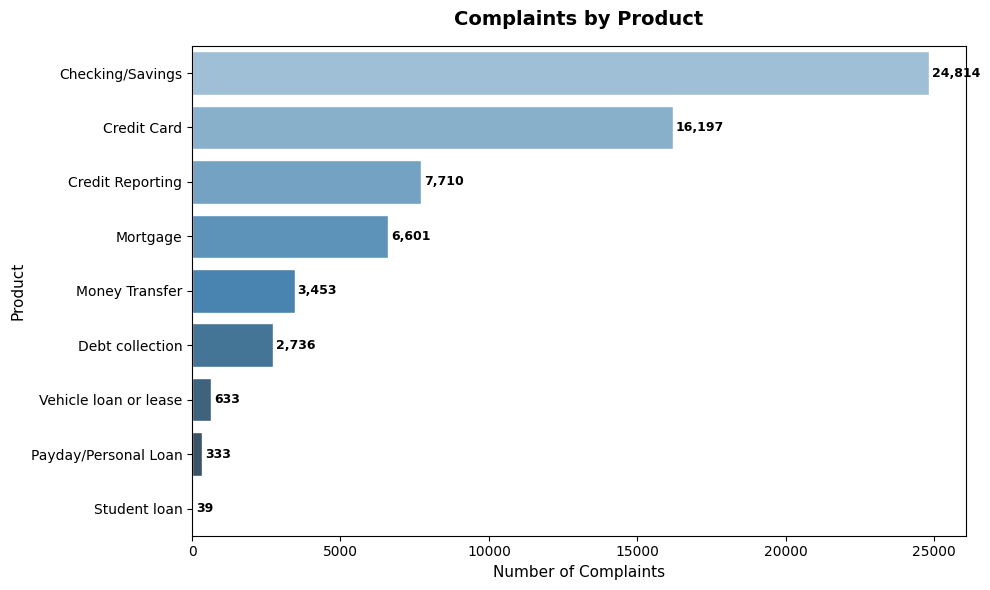

In [19]:
# Data prepare 
product = df['Product'].value_counts().reset_index()
product.columns = ['Product', 'Complaints']

# changing Labels 
short_labels = {
    'Checking or savings account': 'Checking/Savings',
    'Credit card or prepaid card': 'Credit Card',
    'Credit reporting, credit repair services, or other personal consumer reports': 'Credit Reporting',
    'Money transfer, virtual currency, or money service': 'Money Transfer',
    'Payday loan, title loan, or personal loan': 'Payday/Personal Loan',
}
product['Product'] = product['Product'].map(lambda x: short_labels.get(x, x))

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=product, y='Product', x='Complaints',
                 palette='Blues_d', edgecolor='white')

# show bar value at the side of each bar
for bar, val in zip(ax.patches, product['Complaints']):
    ax.text(bar.get_width() + 100,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}',
            va='center', fontsize=9, fontweight='bold')

plt.title('Complaints by Product', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Complaints', fontsize=11)
plt.ylabel('Product', fontsize=11)
plt.tight_layout()
plt.show()

# Monthly Complaints Trend

In [20]:
# Data prepare 
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly = df.groupby('Month_Name').size().reset_index(name='Complaints')

# setting Month in order(otherwise it will short alphabetically)
monthly['Month_Name'] = pd.Categorical(monthly['Month_Name'], 
                                        categories=month_order, 
                                        ordered=True)
monthly = monthly.sort_values('Month_Name')

print(monthly)

   Month_Name  Complaints
4         Jan        4883
3         Feb        4602
7         Mar        5335
0         Apr        5386
8         May        5608
6         Jun        5575
5         Jul        6474
1         Aug        5684
11        Sep        4765
10        Oct        4902
9         Nov        4626
2         Dec        4676


# Line Chart

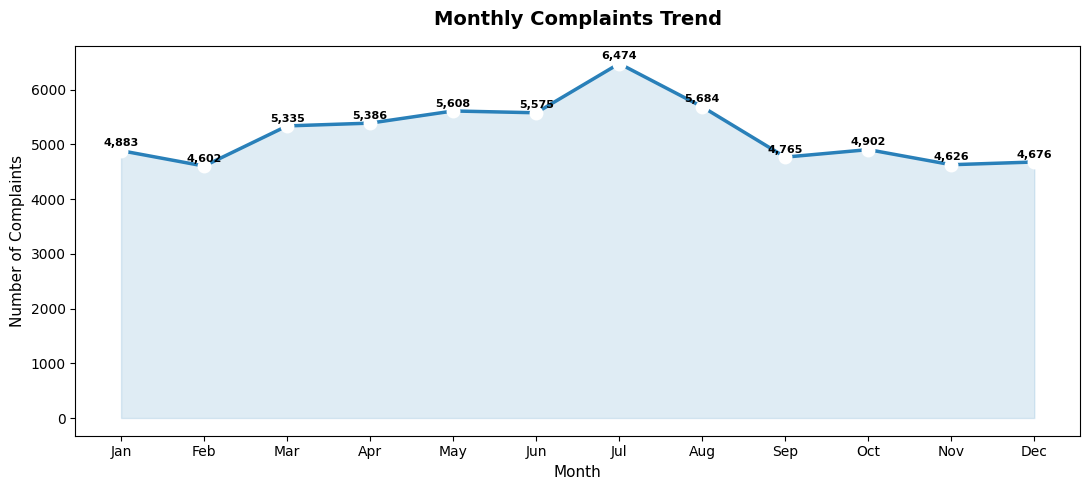

In [21]:
plt.figure(figsize=(11, 5))

ax = sns.lineplot(data=monthly, x='Month_Name', y='Complaints',
                  color='#2980b9', linewidth=2.5, marker='o',
                  markersize=8, markerfacecolor='white',
                  markeredgewidth=2)

# show value in each point
for i, row in monthly.iterrows():
    ax.text(row['Month_Name'], row['Complaints'] + 80,
            f"{row['Complaints']:,}",
            ha='center', fontsize=8, fontweight='bold')

# filling Area to look good 
ax.fill_between(monthly['Month_Name'], monthly['Complaints'],
                alpha=0.15, color='#2980b9')

plt.title('Monthly Complaints Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Number of Complaints', fontsize=11)
plt.tight_layout()
plt.show()

# Day of Week Analysis

In [22]:
# Data prepare 
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
             'Friday', 'Saturday', 'Sunday']

daywise = df.groupby('Day_of_Week').size().reset_index(name='Complaints')

# placing in right order 
daywise['Day_of_Week'] = pd.Categorical(daywise['Day_of_Week'],
                                         categories=day_order,
                                         ordered=True)
daywise = daywise.sort_values('Day_of_Week')

print(daywise)

  Day_of_Week  Complaints
1      Monday        9943
5     Tuesday       11808
6   Wednesday       11549
4    Thursday       10955
0      Friday       10315
2    Saturday        4634
3      Sunday        3312


# Bar Chart with Color Highlight

C:\Users\Namrata\AppData\Local\Temp\ipykernel_3752\529883931.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=daywise, x='Day_of_Week', y='Complaints',


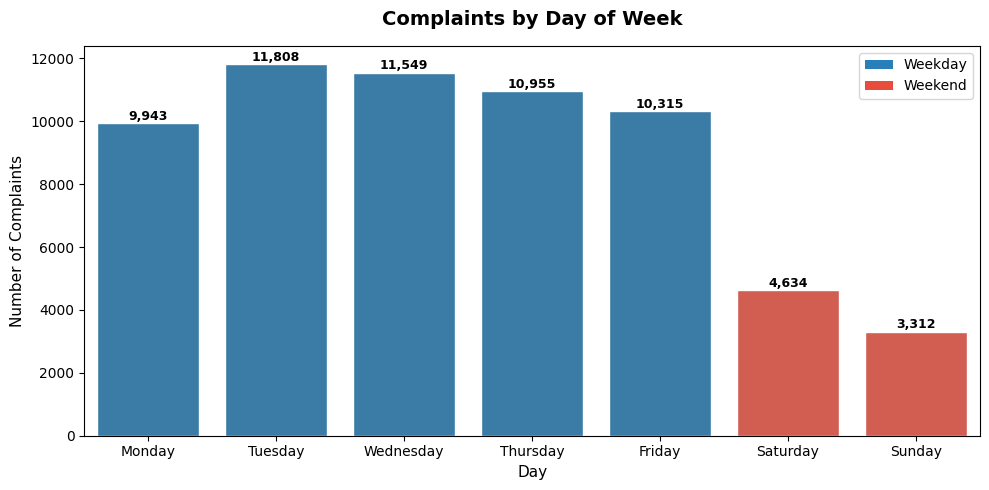

In [23]:
# Weekday/Weekend different color
colors = ['#2980b9' if day not in ['Saturday', 'Sunday'] 
          else '#e74c3c' for day in daywise['Day_of_Week']]

plt.figure(figsize=(10, 5))

ax = sns.barplot(data=daywise, x='Day_of_Week', y='Complaints',
                 palette=colors, edgecolor='white')

# show value on each bar
for bar, val in zip(ax.patches, daywise['Complaints']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{val:,}',
            ha='center', fontsize=9, fontweight='bold')

# created legends manually if seaborn does not make legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2980b9', label='Weekday'),
                   Patch(facecolor='#e74c3c', label='Weekend')]
ax.legend(handles=legend_elements, fontsize=10)

plt.title('Complaints by Day of Week', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day', fontsize=11)
plt.ylabel('Number of Complaints', fontsize=11)
plt.tight_layout()
plt.show()

In [24]:
# Data prepare 
response = df['Company response to consumer'].value_counts().reset_index()
response.columns = ['Response', 'Complaints']

print(response)

                          Response  Complaints
0          Closed with explanation       41044
1      Closed with monetary relief       14697
2  Closed with non-monetary relief        5273
3                      In progress        1494
4                           Closed           8


# Donut Chart

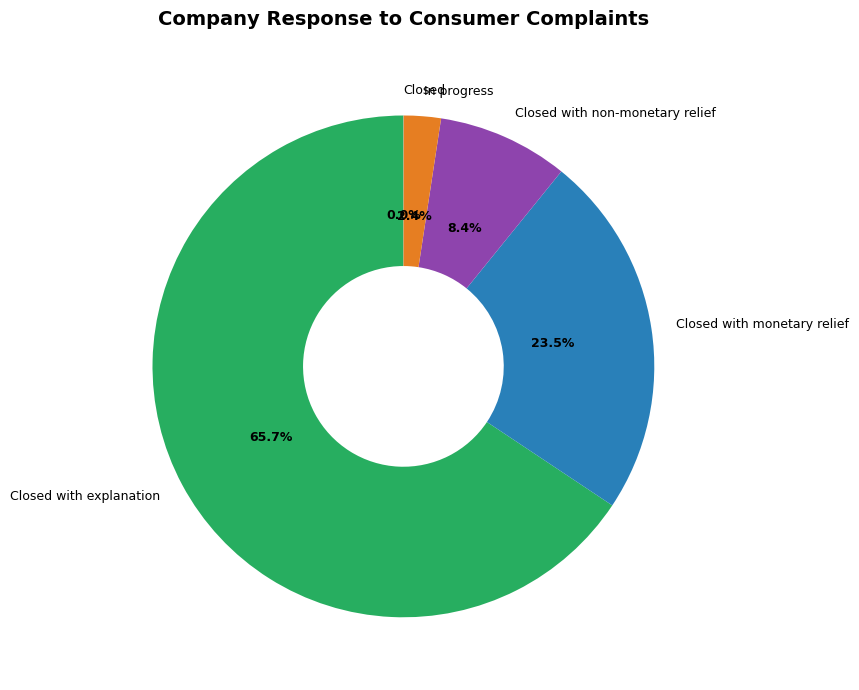

In [25]:
# Colors meaningful
colors = ['#27ae60', '#2980b9', '#8e44ad', '#e67e22', '#95a5a6']

plt.figure(figsize=(9, 7))

wedges, texts, autotexts = plt.pie(
    response['Complaints'],
    labels=response['Response'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'width': 0.6},   # Donut effect
    textprops={'fontsize': 9}
)

# Percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.title('Company Response to Consumer Complaints',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [26]:
# Data prepare 
timely = df['Timely response?'].value_counts().reset_index()
timely.columns = ['Response', 'Count']

print(timely)

  Response  Count
0      Yes  58619
1       No   2403
2  Unknown   1494


C:\Users\Namrata\AppData\Local\Temp\ipykernel_3752\3666895904.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=timely, x='Response', y='Count',


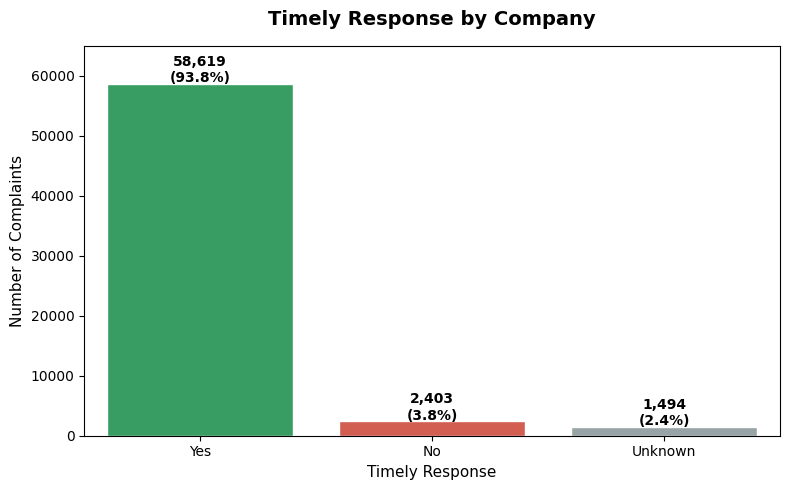

In [27]:
# Grouped Bar with Percentage
# Percentage calculate 
timely['Percentage'] = (timely['Count'] / timely['Count'].sum() * 100).round(1)

colors = ['#27ae60', '#e74c3c', '#95a5a6']

plt.figure(figsize=(8, 5))

ax = sns.barplot(data=timely, x='Response', y='Count',
                 palette=colors, edgecolor='white')

# show bar count and percentage 
for bar, (_, row) in zip(ax.patches, timely.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 300,
            f"{row['Count']:,}\n({row['Percentage']}%)",
            ha='center', fontsize=10, fontweight='bold')

plt.title('Timely Response by Company', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timely Response', fontsize=11)
plt.ylabel('Number of Complaints', fontsize=11)
plt.ylim(0, 65000)
plt.tight_layout()
plt.show()

# Top 10 States Analysis

In [28]:
# Data prepare 
states = df['State'].value_counts().head(10).reset_index()
states.columns = ['State', 'Complaints']

print(states)

  State  Complaints
0    CA       13709
1    FL        6488
2    TX        4686
3    NY        4442
4    GA        2921
5    NJ        2664
6    IL        2270
7    MA        2141
8    MD        1959
9    VA        1731


C:\Users\Namrata\AppData\Local\Temp\ipykernel_3752\3599680345.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=states, y='State', x='Complaints',


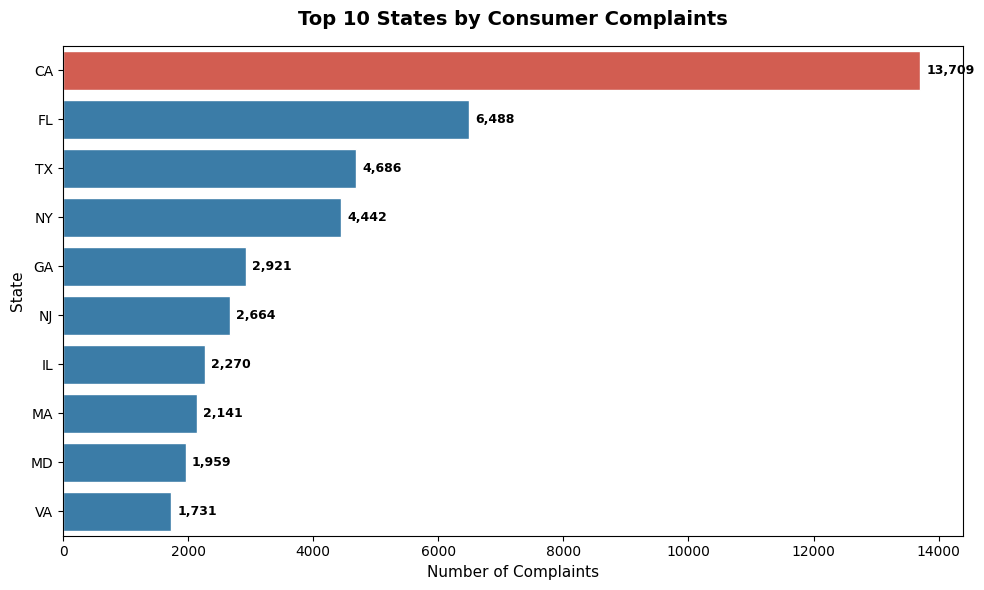

In [29]:
# Horizontal Bar with Color Gradient
plt.figure(figsize=(10, 6))

# separating with Top state 
colors = ['#e74c3c'] + ['#2980b9'] * 9  

ax = sns.barplot(data=states, y='State', x='Complaints',
                 palette=colors, edgecolor='white')

# showing value of each bar
for bar, val in zip(ax.patches, states['Complaints']):
    ax.text(bar.get_width() + 100,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}',
            va='center', fontsize=9, fontweight='bold')

plt.title('Top 10 States by Consumer Complaints',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Complaints', fontsize=11)
plt.ylabel('State', fontsize=11)
plt.tight_layout()
plt.show()

# Insights 1- Complaints are Continuously increasing

In [30]:
yearly = df.groupby('Year').size()

growth = ((yearly[2022] - yearly[2017]) / yearly[2017] * 100).round(1)
peak_year = yearly.idxmax()

print(f"2017 complaints  : {yearly[2017]:,}")
print(f"2022 complaints  : {yearly[2022]:,}")
print(f"Growth (5 years) : {growth}%")
print(f"Peak year        : {peak_year} ({yearly[peak_year]:,} complaints)")

2017 complaints  : 5,394
2022 complaints  : 12,953
Growth (5 years) : 140.1%
Peak year        : 2022 (12,953 complaints)


In [ ]:
#Consumer complaints grew by 140% over 5 years (2017→2022), peaking at 12,953 in 2022. This consistent upward trend suggests 
#growing consumer awareness and increasing financial product issues that require urgent attention

# Insight 2 - Checking Account Sabse Problematic

In [31]:
total = len(df)
product_pct = (df['Product'].value_counts() / total * 100).round(1)

top_product = product_pct.index[0]
top_pct = product_pct.iloc[0]
top2_pct = product_pct.iloc[0] + product_pct.iloc[1]

print(f"Top product      : {top_product}")
print(f"Its share        : {top_pct}%")
print(f"Top 2 combined   : {top2_pct}%")

Top product      : Checking or savings account
Its share        : 39.7%
Top 2 combined   : 65.6%


In [ ]:
# Checking/Savings accounts alone account for 39.7% of all complaints.
#Combined with Credit Cards, just 2 products represent 65.6% of total complaints — indicating these are the highest-risk areas 
#requiring immediate attention

# Insight 3 - Monetary Relief Analysis

In [32]:
total = len(df)
monetary = (df['Company response to consumer'] == 'Closed with monetary relief').sum()
monetary_pct = (monetary / total * 100).round(1)

# which products has the most monetary relief 
monetary_df = df[df['Company response to consumer'] == 'Closed with monetary relief']
top_monetary = (monetary_df['Product'].value_counts().head(3))

print(f"Total monetary relief cases : {monetary:,}")
print(f"Percentage                  : {monetary_pct}%")
print()
print("Top products with monetary relief:")
print(top_monetary)

Total monetary relief cases : 14,697
Percentage                  : 23.5%

Top products with monetary relief:
Product
Checking or savings account    8027
Credit card or prepaid card    4798
Mortgage                        750
Name: count, dtype: int64


In [ ]:
# 1 in 4 complaints (23.5%) resulted in monetary relief for consumers. Checking/Savings accounts had the 
#highest monetary relief cases (8,027), suggesting 
#banks frequently overcharge or make errors in basic account management.

# # Insight 4 - Weekend vs Weekday Pattern

In [35]:
weekday = df[df['Day_of_Week'].isin(['Monday','Tuesday',
            'Wednesday','Thursday','Friday'])].shape[0]
weekend = df[df['Day_of_Week'].isin(['Saturday','Sunday'])].shape[0]

weekday_avg = int(weekday / 5)
weekend_avg = int(weekend / 2)

print(f"Weekday total    : {weekday:,}")
print(f"Weekend total    : {weekend:,}")
print(f"Avg per weekday  : {weekday_avg:,}")
print(f"Avg per weekend  : {weekend_avg:,}")

Weekday total    : 54,570
Weekend total    : 7,946
Avg per weekday  : 10,914
Avg per weekend  : 3,973


In [ ]:
# Weekdays receive 6.9x more complaints than weekends (10,914 vs 3,973 daily average).
#This suggests consumers primarily file complaints during business hours — possibly because they need to reference bank statements 
#or call customer service while doing so."

# Insight 5 — Response Time Analysis

In [36]:
# Average response time by product
short_labels = {
    'Checking or savings account': 'Checking/Savings',
    'Credit card or prepaid card': 'Credit Card',
    'Credit reporting, credit repair services, or other personal consumer reports': 'Credit Reporting',
    'Money transfer, virtual currency, or money service': 'Money Transfer',
    'Payday loan, title loan, or personal loan': 'Payday/Personal Loan',
}

response_time = df.groupby('Product')['Response_Days'].mean().round(1)
response_time.index = [short_labels.get(p, p) for p in response_time.index]
response_time = response_time.sort_values(ascending=False)

print("Avg Response Days by Product:")
print(response_time)

Avg Response Days by Product:
Student loan             2.1
Mortgage                 1.9
Payday/Personal Loan     1.7
Debt collection          1.6
Vehicle loan or lease    1.4
Checking/Savings         1.2
Credit Card              1.1
Money Transfer           1.1
Credit Reporting         0.7
Name: Response_Days, dtype: float64


In [ ]:
# Student Loans and Mortgages take the longest to respond (2.1 and 1.9 days avg) — likely due to their complex nature. 
# Credit Reporting complaints are resolved fastest (0.7 days), 
# possibly due to standardized processes

In [42]:
df.to_csv('complaints_cleaned.csv', index=False)
print("File saved!")

File saved!


In [43]:
import os
print(os.getcwd())

C:\Users\Namrata\Desktop\jupiter cllass_files
